# Data Analysis at 3rd DFT Dataset.


This dataset is the 'corrected' version of the original strain + randomic noises sampling.

It refers to files located at: **📂 [../data/raw/LDA_Dataset3_PWOS](../data/raw/LDA_Dataset3_PWOS)**



In [1]:
import ase.io as io 
from ase import Atoms

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use("../mpl_themes/mestrado.mplstyle")

In [2]:
from pathlib import Path

In [3]:
def get_force_df(atoms: list[Atoms], filenames: list[Path]) -> pd.DataFrame:
    """Return a long dataframe containing all the forces acting on a list of atoms."""

    dados_forcas = []

    for i, snapshot in enumerate(atoms):
        forces = snapshot.get_forces()

        for idx_atomo, vetor_forca in enumerate(forces):
            symbols: list[str] = snapshot.get_chemical_symbols()
            dados_forcas.append({
                "filename": filenames[i].name,  # Número do snapshot (0, 1, 2...)
                "atom": symbols[idx_atomo],  # Índice do átomo dentro do frame
                "Fx": vetor_forca[0],
                "Fy": vetor_forca[1],
                "Fz": vetor_forca[2],
            })

    df_forcas = pd.DataFrame(dados_forcas)
    return df_forcas


def extract_strain_factor(filename: str, which: str) -> float:
    """Extract the strain factor from a pwscf output file."""
    if which == "fa":
        factor = filename.split("-")[2][2:]
    elif which == "fc":
        factor = filename.split("-")[3][2:]
    return float(factor)


def extract_sigma_displacement(filename: str) -> float:
    """Extract the sigma displacement from a pwscf output file."""
    sigma: float = filename.removesuffix(".out").split("-")[-1][1:]
    return float(sigma)

In [4]:
dataset = sorted(Path("../data/raw/LDA_Dataset3_PWOS").glob("*.out"))
ase_atoms = []
print(dataset)


for f in dataset:
    # Try to read the pwscf output and if it fails, skip the file
    try:
        atoms = io.read(f, format="espresso-out")
        ase_atoms.append(atoms)
    except Exception as e:
        print(f"Failed to read {f}: {e}")
        continue        

    

[PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.90-n0.000.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.90-n0.025.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.90-n0.040.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.90-n0.060.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.92-n0.000.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.92-n0.025.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.92-n0.040.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.92-n0.060.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.94-n0.000.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.94-n0.025.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.94-n0.040.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.94-n0.060.out'), PosixPath('../data/raw/LDA_Dataset3_PWOS/ZnO-111-fa0.90-fc0.96-n0.000.out')

In [5]:
filenames = [f.name for f in dataset]


In [ ]:
# filenames[0].removesuffix(".out").split("-")
# filenames[0].removesuffix(".out").split("-")[-1][1:]
# filenames[0].split("-")[2][2:]

In [6]:
df_forcas = get_force_df(ase_atoms, dataset)
df_forcas

,filename,atom,Fx,Fy,Fz
0,ZnO-111-fa0.90-fc0.90-n0.000.out,Zn,0.000000,-0.000000,-0.002762
1,ZnO-111-fa0.90-fc0.90-n0.000.out,Zn,-0.000000,0.000000,-0.002762
2,ZnO-111-fa0.90-fc0.90-n0.000.out,O,0.000000,0.000000,0.002762
3,ZnO-111-fa0.90-fc0.90-n0.000.out,O,0.000000,-0.000000,0.002762
4,ZnO-111-fa0.90-fc0.90-n0.025.out,Zn,0.582833,-0.155630,-1.800638
...,...,...,...,...,...
121951,ZnO-331-fa1.10-fc1.10-n0.040.out,O,-0.130848,0.273052,0.438351
121952,ZnO-331-fa1.10-fc1.10-n0.040.out,Zn,-0.380135,0.320501,0.267767
121953,ZnO-331-fa1.10-fc1.10-n0.040.out,Zn,-0.394799,-0.136226,0.003712
121954,ZnO-331-fa1.10-fc1.10-n0.040.out,O,0.504975,-0.164103,-0.099098


In [7]:
# Colunas auxiliares
df_forcas["F"] = np.sqrt(df_forcas["Fx"]**2 + df_forcas["Fy"]**2 + df_forcas["Fz"]**2)
df_forcas["fa"] = df_forcas["filename"].apply(lambda x: extract_strain_factor(x, "fa"))
df_forcas["fc"] = df_forcas["filename"].apply(lambda x: extract_strain_factor(x, "fc"))
df_forcas["sigma"] = df_forcas["filename"].apply(lambda x: extract_sigma_displacement(x))

In [8]:
df_forcas

,filename,atom,Fx,Fy,Fz,F,fa,fc,sigma
0,ZnO-111-fa0.90-fc0.90-n0.000.out,Zn,0.000000,-0.000000,-0.002762,0.002762,0.9,0.9,0.000
1,ZnO-111-fa0.90-fc0.90-n0.000.out,Zn,-0.000000,0.000000,-0.002762,0.002762,0.9,0.9,0.000
2,ZnO-111-fa0.90-fc0.90-n0.000.out,O,0.000000,0.000000,0.002762,0.002762,0.9,0.9,0.000
3,ZnO-111-fa0.90-fc0.90-n0.000.out,O,0.000000,-0.000000,0.002762,0.002762,0.9,0.9,0.000
4,ZnO-111-fa0.90-fc0.90-n0.025.out,Zn,0.582833,-0.155630,-1.800638,1.899003,0.9,0.9,0.025
...,...,...,...,...,...,...,...,...,...
121951,ZnO-331-fa1.10-fc1.10-n0.040.out,O,-0.130848,0.273052,0.438351,0.532757,1.1,1.1,0.040
121952,ZnO-331-fa1.10-fc1.10-n0.040.out,Zn,-0.380135,0.320501,0.267767,0.564732,1.1,1.1,0.040
121953,ZnO-331-fa1.10-fc1.10-n0.040.out,Zn,-0.394799,-0.136226,0.003712,0.417657,1.1,1.1,0.040
121954,ZnO-331-fa1.10-fc1.10-n0.040.out,O,0.504975,-0.164103,-0.099098,0.540139,1.1,1.1,0.040


---

## Dispersion of $\left| \vec{F} \right|$    grouped by $\sigma$

In [25]:
df_forcas

,filename,atom,Fx,Fy,Fz,F,fa,fc,sigma
0,ZnO-111-fa0.90-fc0.90-n0.000.out,Zn,0.000000,-0.000000,-0.002762,0.002762,0.9,0.9,0.000
1,ZnO-111-fa0.90-fc0.90-n0.000.out,Zn,-0.000000,0.000000,-0.002762,0.002762,0.9,0.9,0.000
2,ZnO-111-fa0.90-fc0.90-n0.000.out,O,0.000000,0.000000,0.002762,0.002762,0.9,0.9,0.000
3,ZnO-111-fa0.90-fc0.90-n0.000.out,O,0.000000,-0.000000,0.002762,0.002762,0.9,0.9,0.000
4,ZnO-111-fa0.90-fc0.90-n0.025.out,Zn,0.582833,-0.155630,-1.800638,1.899003,0.9,0.9,0.025
...,...,...,...,...,...,...,...,...,...
121951,ZnO-331-fa1.10-fc1.10-n0.040.out,O,-0.130848,0.273052,0.438351,0.532757,1.1,1.1,0.040
121952,ZnO-331-fa1.10-fc1.10-n0.040.out,Zn,-0.380135,0.320501,0.267767,0.564732,1.1,1.1,0.040
121953,ZnO-331-fa1.10-fc1.10-n0.040.out,Zn,-0.394799,-0.136226,0.003712,0.417657,1.1,1.1,0.040
121954,ZnO-331-fa1.10-fc1.10-n0.040.out,O,0.504975,-0.164103,-0.099098,0.540139,1.1,1.1,0.040


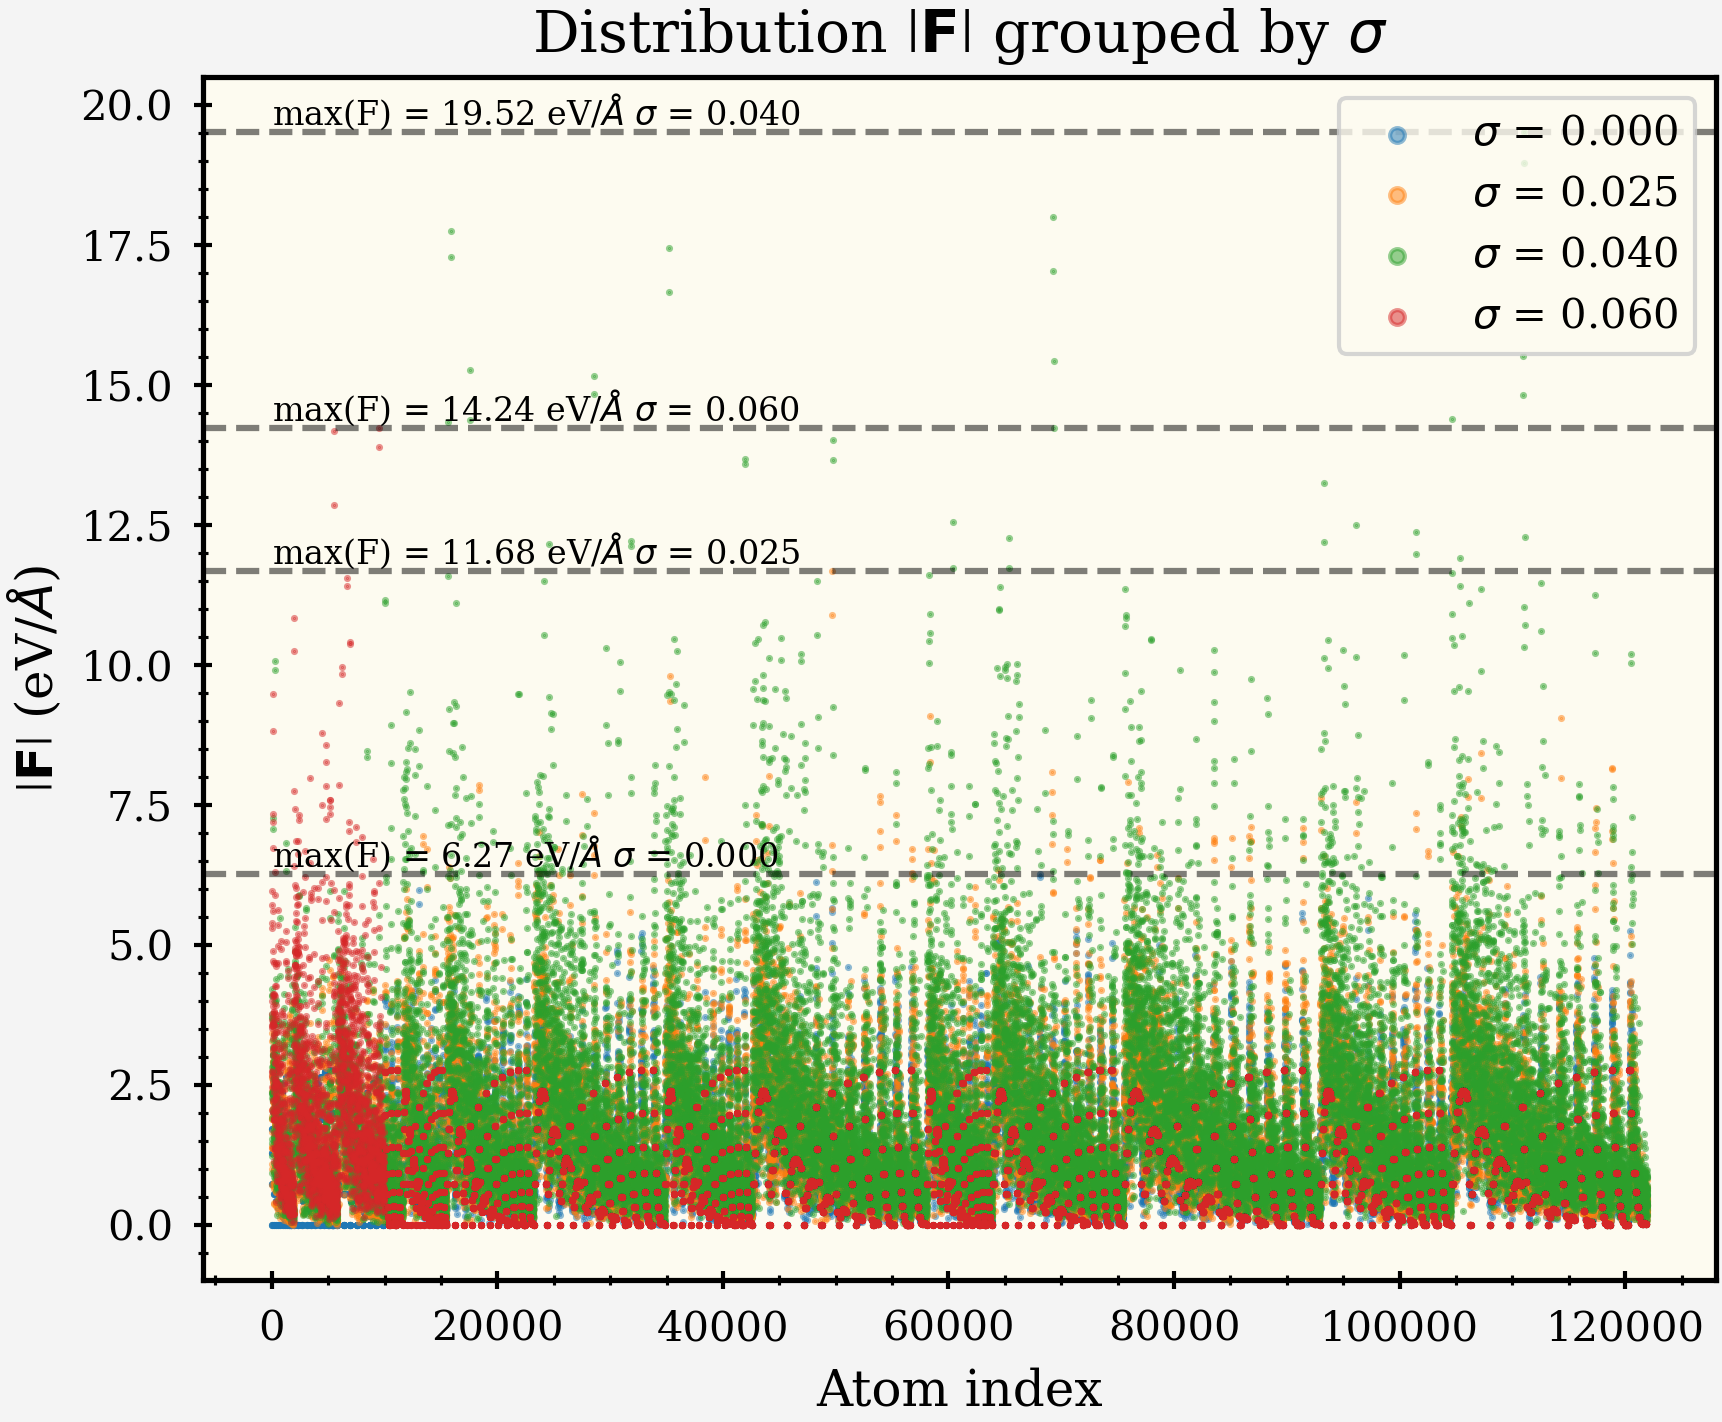

In [44]:
sigmas = df_forcas["sigma"].unique()
max_force_by_sigma = []


fig, ax = plt.subplots(figsize=(6, 5))
ax.set_title(r"Distribution $\left| \mathbf{F} \right|$ grouped by $\sigma$")
ax.set_ylabel(r"$\left| \mathbf{F} \right|$ (eV/$\AA$)")
ax.set_xlabel("Atom index")



for sigma in sigmas:
    df_sigma = df_forcas[df_forcas["sigma"] == sigma]
    # statistics 
    max_force = df_sigma["F"].max()
    max_force_by_sigma.append((sigma, max_force))
    

    # plotting

    # ax.hist(df_sigma["F"], bins=30, alpha=0.5, label=f"$\sigma$={sigma:.3f}")
    ax.scatter(df_sigma["F"].index, df_sigma["F"], s=0.5, alpha=0.5, label=fr"$\sigma$ = {sigma:.3f}")



for sigma, max_force in max_force_by_sigma:
    ax.axhline(y=max_force, color='black', linestyle='--', alpha=0.5)
    # text the value near the horizontal line
    text = fr"max(F) = {max_force:.2f} eV/$\AA$ $\sigma$ = {sigma:.3f}"
    ax.text(0, max_force, text, color='black', fontsize=8, verticalalignment='bottom')

ax.grid(False)
ax.legend(loc='upper right', markerscale=5)
plt.show()

---